In [2]:
import pandas as pd

# Scrape a Wikipedia table (example: list of industries)
url = "https://en.wikipedia.org/wiki/List_of_largest_employers"

headers = {"user-Agent": "Mozilla/5.0"}
tables = pd.read_html(url, storage_options={"user-Agent": "Mozilla/5.0"})

# Get the first table
df = tables[0]
print(df.head())

   Rank                             Employer  Employees (mn)        Country  \
0     1          Ministry of Defence (India)            2.99          India   
1     2  United States Department of Defense            2.91  United States   
2     3             People's Liberation Army            2.55          China   
3     4                              Walmart            2.30  United States   
4     5                               Amazon            1.61  United States   

  State-owned  Ref  
0         Yes  [1]  
1         Yes  [1]  
2         Yes  [1]  
3          No  [1]  
4          No  [1]  


In [5]:
df.to_csv("../data/employers.csv", index=False)
print("saved!")

saved!


In [8]:
print(df.head())
print(df.info())
print(df.describe())

   Rank                             Employer  Employees (mn)        Country  \
0     1          Ministry of Defence (India)            2.99          India   
1     2  United States Department of Defense            2.91  United States   
2     3             People's Liberation Army            2.55          China   
3     4                              Walmart            2.30  United States   
4     5                               Amazon            1.61  United States   

  State-owned  Ref  
0         Yes  [1]  
1         Yes  [1]  
2         Yes  [1]  
3          No  [1]  
4          No  [1]  
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rank            10 non-null     int64  
 1   Employer        10 non-null     str    
 2   Employees (mn)  10 non-null     float64
 3   Country         10 non-null     str    
 4   State-owned     10 non-null     st

In [11]:
df = df.fillna("Uknown")
print("successful")

successful


In [12]:
df.to_csv("../data/employers_clean.csv", index=False)
print("clean data saved!")

clean data saved!


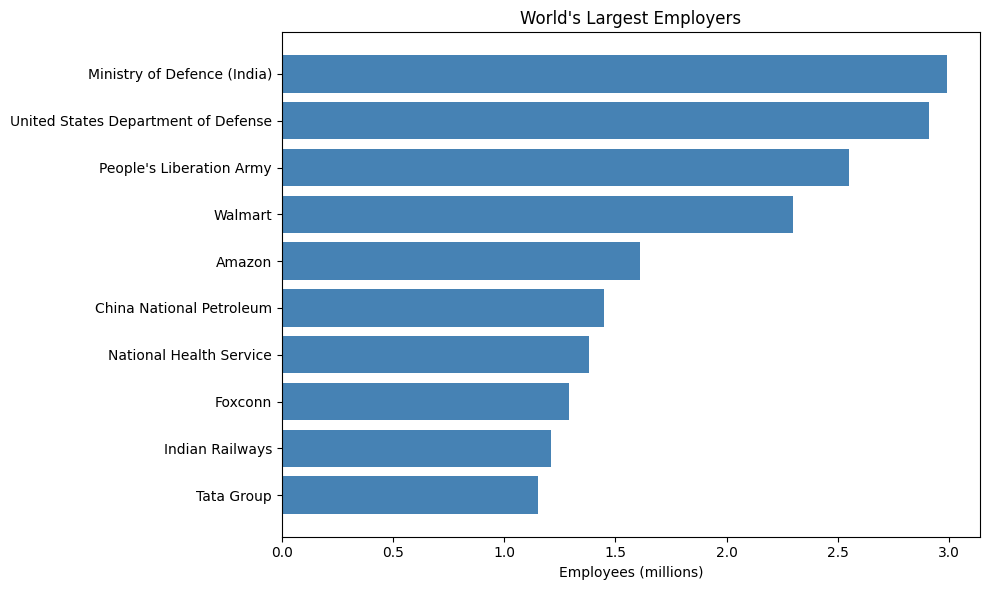

In [13]:
import matplotlib.pyplot as plt

# Bar chart of largest employers
plt.figure(figsize=(10, 6))
plt.barh(df["Employer"], df["Employees (mn)"], color="steelblue")
plt.xlabel("Employees (millions)")
plt.title("World's Largest Employers")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../charts/largest_employers.png")
plt.show()

In [19]:
df.sort_values(by="Employer", ascending=False)

,Rank,Employer,Employees (mn),Country,State-owned,Ref
3,4,Walmart,2.30,United States,No,[1]
1,2,United States Department of Defense,2.91,United States,Yes,[1]
9,10,Tata Group,1.15,India,No,[3]
2,3,People's Liberation Army,2.55,China,Yes,[1]
6,7,National Health Service,1.38,United Kingdom,Yes,[1]
0,1,Ministry of Defence (India),2.99,India,Yes,[1]
8,9,Indian Railways,1.21,India,Yes,[2]
7,8,Foxconn,1.29,Taiwan,No,[1]
5,6,China National Petroleum,1.45,China,Yes,[1]
4,5,Amazon,1.61,United States,No,[1]


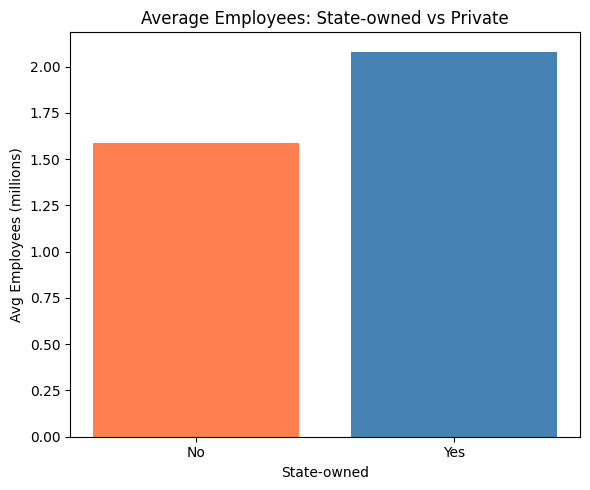

In [20]:
state_group = df.groupby("State-owned")["Employees (mn)"].mean()
plt.figure(figsize=(6, 5))
plt.bar(state_group.index, state_group.values, color=["coral", "steelblue"])
plt.title("Average Employees: State-owned vs Private")
plt.xlabel("State-owned")
plt.ylabel("Avg Employees (millions)")
plt.tight_layout()
plt.savefig("../charts/state_vs_private.png")
plt.show()

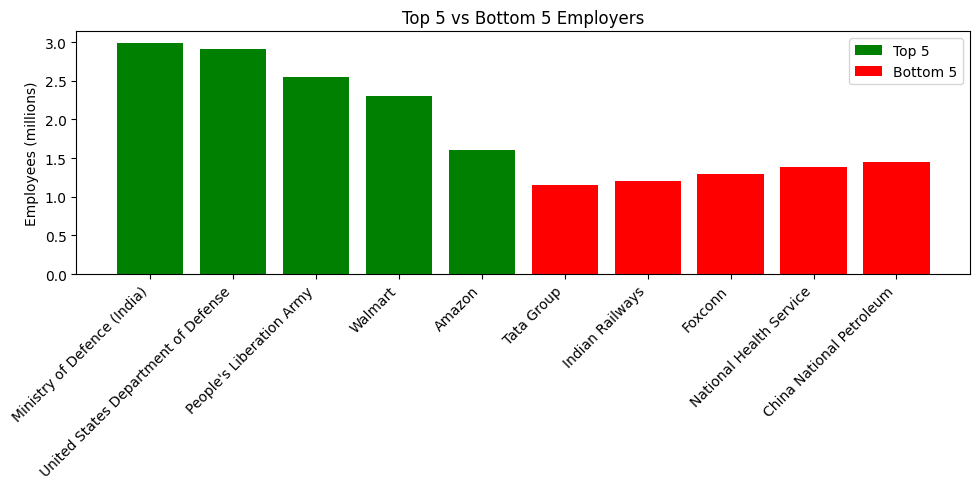

In [21]:
top5 = df.nlargest(5, "Employees (mn)")
bottom5 = df.nsmallest(5, "Employees (mn)")

plt.figure(figsize=(10, 5))
plt.bar(top5["Employer"], top5["Employees (mn)"], color="green", label="Top 5")
plt.bar(bottom5["Employer"], bottom5["Employees (mn)"], color="red", label="Bottom 5")
plt.title("Top 5 vs Bottom 5 Employers")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Employees (millions)")
plt.legend()
plt.tight_layout()
plt.savefig("../charts/top_vs_bottom.png")
plt.show()

In [22]:
total = df["Employees (mn)"].sum()
df["Market Share %"] = (df["Employees (mn)"] / total * 100).round(2)

print(df[["Employer", "Employees (mn)", "Market Share %"]])

                              Employer  Employees (mn)  Market Share %
0          Ministry of Defence (India)            2.99           15.87
1  United States Department of Defense            2.91           15.45
2             People's Liberation Army            2.55           13.54
3                              Walmart            2.30           12.21
4                               Amazon            1.61            8.55
5             China National Petroleum            1.45            7.70
6              National Health Service            1.38            7.32
7                              Foxconn            1.29            6.85
8                      Indian Railways            1.21            6.42
9                           Tata Group            1.15            6.10


In [23]:
state = df[df["State-owned"] == "Yes"]["Employees (mn)"]
private = df[df["State-owned"] == "No"]["Employees (mn)"]

print("STATE-OWNED:")
print(f"  Mean: {state.mean():.2f}mn")
print(f"  Std Dev: {state.std():.2f}mn")
print(f"  Max: {state.max():.2f}mn")

print("\nPRIVATE:")
print(f"  Mean: {private.mean():.2f}mn")
print(f"  Std Dev: {private.std():.2f}mn")
print(f"  Max: {private.max():.2f}mn")

STATE-OWNED:
  Mean: 2.08mn
  Std Dev: 0.82mn
  Max: 2.99mn

PRIVATE:
  Mean: 1.59mn
  Std Dev: 0.51mn
  Max: 2.30mn


In [24]:
print("===== JOB MARKET ANALYSIS REPORT =====")
print(f"\nTotal Employers Analyzed: {len(df)}")
print(f"Total Employees Covered: {df['Employees (mn)'].sum():.2f} million")
print(f"\nLargest Employer: {df.loc[df['Employees (mn)'].idxmax(), 'Employer']}")
print(f"Smallest Employer: {df.loc[df['Employees (mn)'].idxmin(), 'Employer']}")
print(f"\nMost Represented Country: {df['Country'].value_counts().index[0]}")
print(f"\nState-owned employers: {len(df[df['State-owned']=='Yes'])}")
print(f"Private employers: {len(df[df['State-owned']=='No'])}")
print(f"\nWorkforce Inequality (Std Dev): {df['Employees (mn)'].std():.2f}mn")

===== JOB MARKET ANALYSIS REPORT =====

Total Employers Analyzed: 10
Total Employees Covered: 18.84 million

Largest Employer: Ministry of Defence (India)
Smallest Employer: Tata Group

Most Represented Country: India

State-owned employers: 6
Private employers: 4

Workforce Inequality (Std Dev): 0.73mn
